In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import ast
import os

In [33]:
df = pd.read_csv('./data/df_alter.csv')

In [34]:
mask1 = df['in_gcc'] == False
mask2 = df['name'] == 'social networks'
no_AI = list(df[mask1 & mask2]['participant_id'])

df_noAI = df[df['participant_id'].isin(no_AI)].copy()

In [42]:
df[mask1]['participant_id'].unique()

array(['cmh1uot9n000osa27eayyicd9', 'cmh21d16h002ksa27lkj9ip6g',
       'cmh291q1v002vsa27a241pgye', 'cmh20nti10021sa2781v0n7gr',
       'cmh205bqc001qsa273cbrl5cg', 'cmh4n1pe9003gsa27d06mabf0'],
      dtype=object)

In [36]:


# ---------- USER PARAMS ----------
INPUT_DF = "df"              # assumes df already loaded in your session (pandas DataFrame)
OUT_DIR = "./data/per_participant_edges"
WRITE_GRAPHML = True         # set False if you don't want per-participant GraphML files
UUID_COL = "networkCanvasUUID"
NAME_COL = "name"
CONNECTED_COL = "connected_concepts"
# screen-space columns (preferred). If missing, script will try user_layout_x/y
SCREEN_X = "user_layout_screenSpaceX"
SCREEN_Y = "user_layout_screenSpaceY"
ALT_X = "user_layout_x"
ALT_Y = "user_layout_y"
# ---------------------------------

os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Helper to parse connected_concepts ----------
def parse_connected(s):
    """Return a list of UUID strings parsed from the 'connected_concepts' cell."""
    if pd.isna(s):
        return []
    if isinstance(s, list):
        return [str(x) for x in s]
    try:
        val = ast.literal_eval(s)
        if isinstance(val, (list, tuple)):
            return [str(x) for x in val]
    except Exception:
        # fallback: strip [] and split by comma
        s2 = str(s).strip("[]() ")
        if not s2:
            return []
        parts = [p.strip().strip("'\"") for p in s2.split(",") if p.strip()]
        return parts
    return []

# ---------- Prepare df_noAI according to your masks ----------
# If you already have df_noAI in memory, comment out the block below.
# Otherwise, if 'df' DataFrame is loaded in this environment, it will create df_noAI exactly as you specified.
try:
    df  # noqa: F821
except NameError:
    raise RuntimeError("This script expects a pandas DataFrame named `df` to be present in the environment.")

mask1 = df['in_gcc'] == False
mask2 = df['name'].str.lower() == 'social networks'
no_AI = list(df[mask1 & mask2]['participant_id'].unique())
df_noAI = df[df['participant_id'].isin(no_AI)].copy()

# ---------- iterate participants and write per-participant edge lists ----------
summary = []
for pid, sub in df_noAI.groupby("participant_id"):
    # mapping per participant: UUID -> name
    id_to_name = {str(r[UUID_COL]): r[NAME_COL] for _, r in sub.iterrows() if pd.notna(r.get(UUID_COL))}
    # also build a dict for coordinates keyed by concept name
    coords = {}
    for _, r in sub.iterrows():
        name = r[NAME_COL]
        # prefer screen-space coords if present, else fallback to normalized layout coords
        x = r.get(SCREEN_X) if SCREEN_X in sub.columns else None
        y = r.get(SCREEN_Y) if SCREEN_Y in sub.columns else None
        if (pd.isna(x) or pd.isna(y)) and (ALT_X in sub.columns and ALT_Y in sub.columns):
            # fallback: may need to scale these later — keep raw
            x = r.get(ALT_X)
            y = r.get(ALT_Y)
        # coerce to float if possible, else None
        try:
            x = float(x) if pd.notna(x) else None
        except Exception:
            x = None
        try:
            y = float(y) if pd.notna(y) else None
        except Exception:
            y = None
        coords[name] = (x, y)

    # collect raw edges as unordered pairs (use names)
    edge_set = set()
    for _, r in sub.iterrows():
        src_uuid = r.get(UUID_COL)
        if pd.isna(src_uuid):
            continue
        src_uuid = str(src_uuid)
        src_name = id_to_name.get(src_uuid, None)
        if src_name is None:
            # skip rows where we cannot map the uuid -> name (defensive)
            continue
        connected_raw = r.get(CONNECTED_COL, None)
        other_uuids = parse_connected(connected_raw)
        for other_uuid in other_uuids:
            other_uuid = str(other_uuid)
            tgt_name = id_to_name.get(other_uuid, None)
            if tgt_name is None:
                # skip if the target uuid isn't present in this participant's canvas
                continue
            # unordered pair (so (a,b) == (b,a))
            if src_name == tgt_name:
                continue
            a, b = sorted([src_name, tgt_name])
            edge_set.add((a, b))

    # build DataFrame for edges with coordinates
    rows = []
    for a, b in sorted(edge_set):
        xa, ya = coords.get(a, (None, None))
        xb, yb = coords.get(b, (None, None))
        rows.append({
            "source": a,
            "target": b,
            "x_source": xa,
            "y_source": ya,
            "x_target": xb,
            "y_target": yb,
            "participant_id": pid
        })
    edges_df = pd.DataFrame(rows)

    # output CSV per participant
    fname = f"edges_{pid}.csv"
    out_path = os.path.join(OUT_DIR, fname)
    edges_df.to_csv(out_path, index=False)

    # optional: also output GraphML with node positions and in_gcc flag
    if WRITE_GRAPHML:
        G = nx.Graph()
        # add nodes from participant sub
        for _, r in sub.iterrows():
            name = r[NAME_COL]
            x, y = coords.get(name, (None, None))
            in_gcc_val = r.get("in_gcc")
            # normalize in_gcc to boolean if possible
            in_gcc_bool = (str(in_gcc_val).lower() == "true") if pd.notna(in_gcc_val) else None
            # store coords (GraphML requires strings for attributes to be safe)
            attrs = {"in_gcc": str(in_gcc_bool), "x": str(x) if x is not None else "", "y": str(y) if y is not None else ""}
            G.add_node(name, **attrs)
        # add edges from edge_set
        for a, b in edge_set:
            G.add_edge(a, b)

        graphml_path = os.path.join(OUT_DIR, f"graph_{pid}.graphml")
        # write GraphML; to be robust, convert node attrs to strings only
        # networkx.write_graphml will fail if attributes are non-string for some versions, so ensure str
        G_for_graphml = nx.Graph()
        for n, data in G.nodes(data=True):
            safe_data = {k: ("" if v is None else str(v)) for k, v in data.items()}
            G_for_graphml.add_node(str(n), **safe_data)
        for u, v in G.edges():
            G_for_graphml.add_edge(str(u), str(v))
        nx.write_graphml(G_for_graphml, graphml_path)

    summary.append({
        "participant_id": pid,
        "n_nodes": len(id_to_name),
        "n_edges": len(edge_set),
        "edge_csv": out_path,
        "graphml": graphml_path if WRITE_GRAPHML else ""
    })

# Save a small summary for quick reference
summary_df = pd.DataFrame(summary)
summary_df.to_csv(os.path.join(OUT_DIR, "summary.csv"), index=False)
print("Wrote per-participant edge lists to:", OUT_DIR)
print(summary_df[["participant_id", "n_nodes", "n_edges"]])

Wrote per-participant edge lists to: ./data/per_participant_edges
              participant_id  n_nodes  n_edges
0  cmh205bqc001qsa273cbrl5cg       11        8
1  cmh4n1pe9003gsa27d06mabf0       12        1


Found 6 participants with >1 components: ['cmh1uot9n000osa27eayyicd9', 'cmh205bqc001qsa273cbrl5cg', 'cmh20nti10021sa2781v0n7gr', 'cmh21d16h002ksa27lkj9ip6g', 'cmh291q1v002vsa27a241pgye', 'cmh4n1pe9003gsa27d06mabf0']


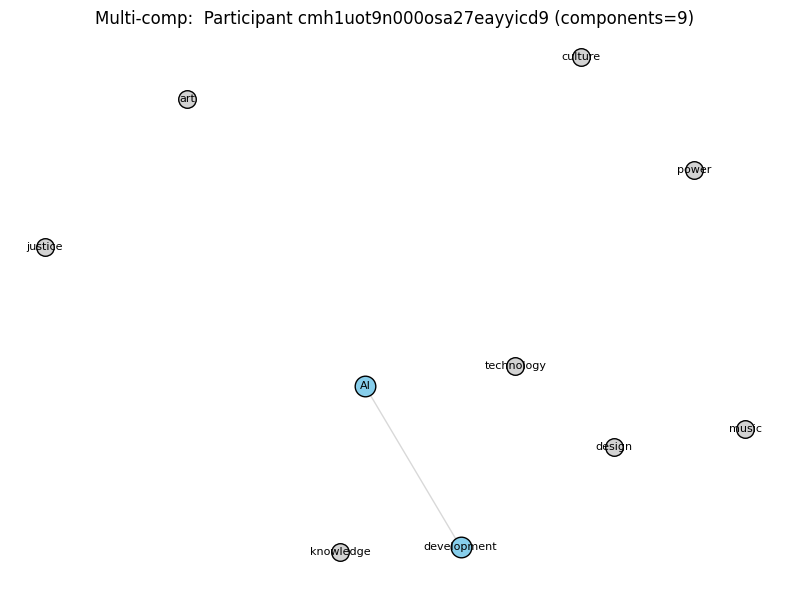

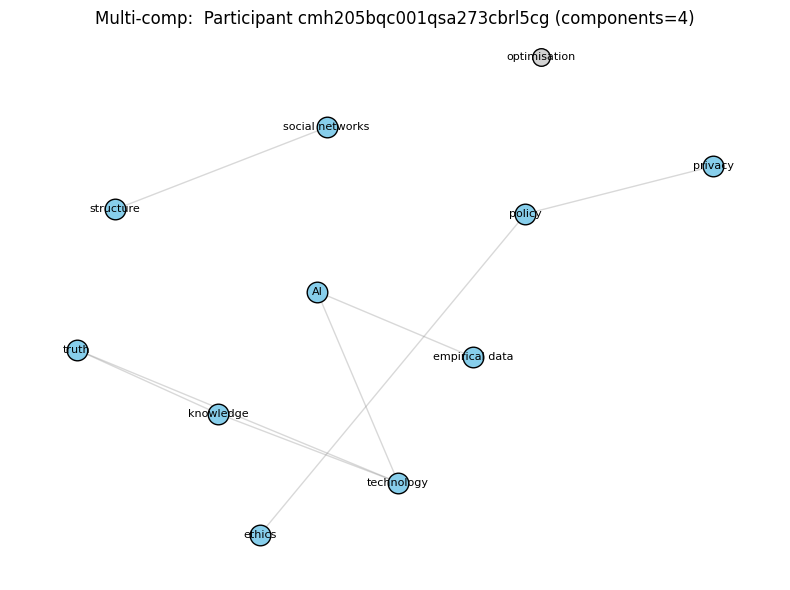

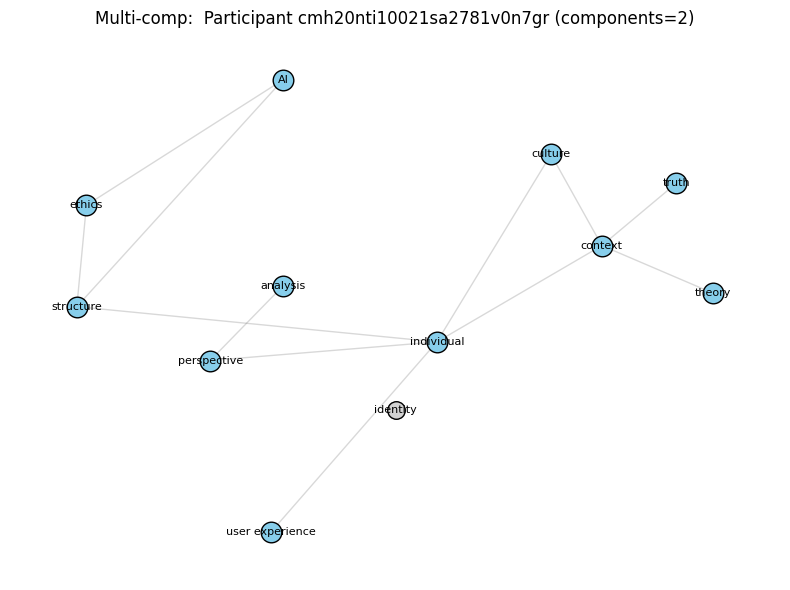

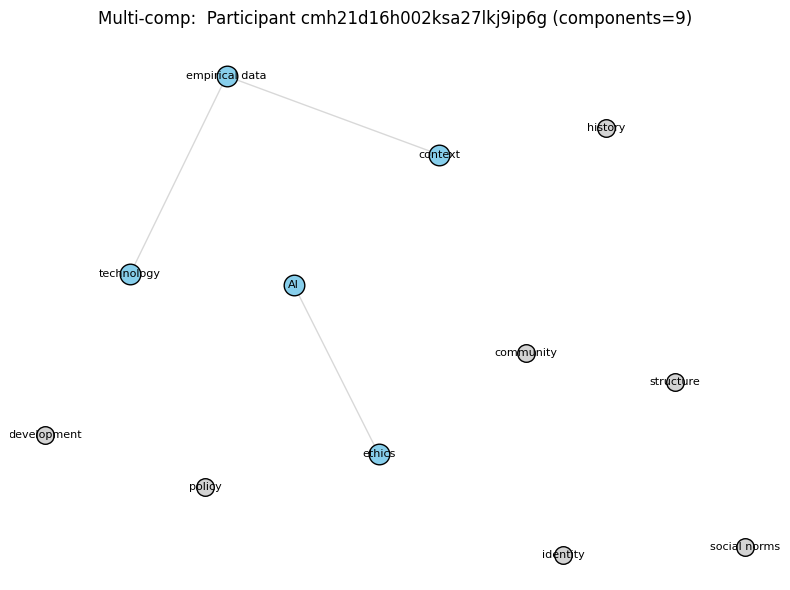

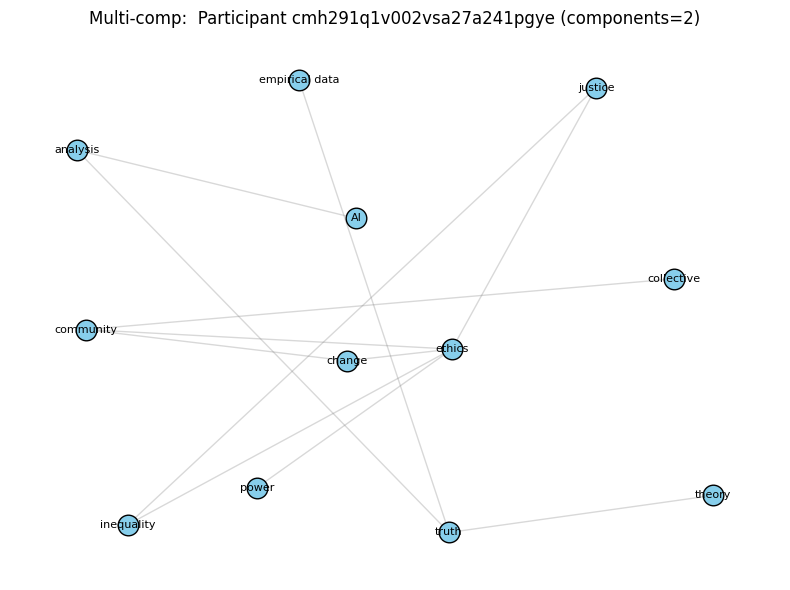

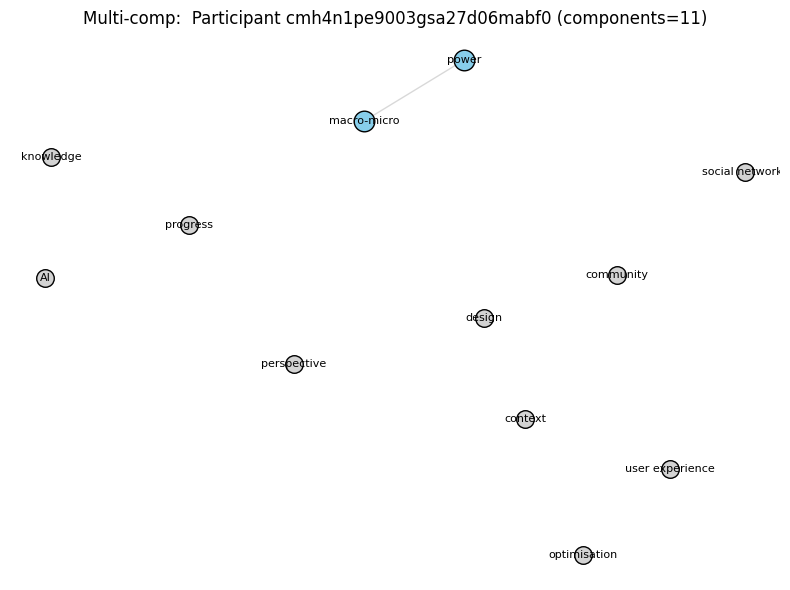

In [ ]:
# Plot all participant maps that have more than one connected component
# (i.e., their reconstructed graph has >1 component)
import os, ast, numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any

OUT_DIR = "./data/per_participant_edges"
os.makedirs(OUT_DIR, exist_ok=True)

# Column names used in the dataframe
UUID_COL = "networkCanvasUUID"
NAME_COL = "name"
CONNECTED_COL = "connected_concepts"
SCREEN_X = "user_layout_screenSpaceX"
SCREEN_Y = "user_layout_screenSpaceY"
ALT_X = "user_layout_x"
ALT_Y = "user_layout_y"

# --- helpers (robust parsing) ---
def parse_connected(cell) -> List[str]:
    if pd.isna(cell):
        return []
    if isinstance(cell, (list, tuple)):
        return [str(x) for x in cell]
    s = str(cell).strip()
    if s == "":
        return []
    try:
        val = ast.literal_eval(s)
        if isinstance(val, (list, tuple)):
            return [str(x) for x in val]
    except Exception:
        pass
    s2 = s.strip("[]() ")
    if not s2:
        return []
    return [p.strip().strip("'\"") for p in s2.split(",") if p.strip()]

def build_coords_map(sub: pd.DataFrame) -> Dict[str, Tuple[Any, Any]]:
    coords = {}
    for _, r in sub.iterrows():
        name = r[NAME_COL]
        x = r.get(SCREEN_X) if SCREEN_X in sub.columns else None
        y = r.get(SCREEN_Y) if SCREEN_Y in sub.columns else None
        if (pd.isna(x) or pd.isna(y)) and (ALT_X in sub.columns and ALT_Y in sub.columns):
            x = r.get(ALT_X)
            y = r.get(ALT_Y)
        try:
            x = float(x) if pd.notna(x) else None
        except Exception:
            x = None
        try:
            y = float(y) if pd.notna(y) else None
        except Exception:
            y = None
        coords[name] = (x, y)
    return coords

def construct_participant_graph(sub: pd.DataFrame) -> nx.Graph:
    """Build graph for a single participant DataFrame `sub` (all rows for that participant)."""
    id_to_name = {str(r[UUID_COL]): r[NAME_COL] for _, r in sub.iterrows() if pd.notna(r.get(UUID_COL))}
    G = nx.Graph()
    # add all nodes (so isolates are included)
    for _, r in sub.iterrows():
        name = r[NAME_COL]
        G.add_node(name)
    # add edges using networkCanvasUUID references in connected_concepts
    for _, r in sub.iterrows():
        src_uuid = r.get(UUID_COL)
        if pd.isna(src_uuid):
            continue
        src_uuid = str(src_uuid)
        src_name = id_to_name.get(src_uuid)
        if src_name is None:
            continue
        neighbors = parse_connected(r.get(CONNECTED_COL, ""))
        for nb in neighbors:
            nb = str(nb)
            tgt_name = id_to_name.get(nb)
            if tgt_name is None:
                continue
            if src_name == tgt_name:
                continue
            G.add_edge(src_name, tgt_name)
    return G

# --- plotting helper with jitter fallback for missing coords (deterministic) ---
def plot_map_from_graph(G: nx.Graph, coords: Dict[str, Tuple[Any, Any]], pid: str,
                        title_prefix: str = "", save: bool = False, jitter_scale: float = 0.03):
    # prepare known positions (flip Y for plotting)
    pos_known = {}
    for n, (x, y) in coords.items():
        if x is not None and y is not None and not (np.isnan(x) or np.isnan(y)):
            pos_known[n] = (float(x), -float(y))
    # missing nodes
    missing_nodes = [n for n in G.nodes if n not in pos_known]
    pos_complete = dict(pos_known)
    if len(pos_known) > 0:
        xs = np.array([p[0] for p in pos_known.values()])
        ys = np.array([p[1] for p in pos_known.values()])
        x_span = xs.max() - xs.min() if xs.max() != xs.min() else max(1.0, abs(xs.max()))
        y_span = ys.max() - ys.min() if ys.max() != ys.min() else max(1.0, abs(ys.max()))
        jitter_x = jitter_scale * x_span
        jitter_y = jitter_scale * y_span
        centroid = (xs.mean(), ys.mean())
        rng = np.random.default_rng(seed=42)
        for i, n in enumerate(missing_nodes):
            jitter_pos = (centroid[0] + rng.uniform(-1,1) * jitter_x + (i % 5) * jitter_x * 0.15,
                          centroid[1] + rng.uniform(-1,1) * jitter_y + (i // 5) * jitter_y * 0.15)
            pos_complete[n] = jitter_pos
    else:
        # fallback to spring layout for entire graph
        spring_pos = nx.spring_layout(G, seed=42)
        for n, p in spring_pos.items():
            pos_complete[n] = (p[0]*1000.0, -p[1]*1000.0)

    isolates = list(nx.isolates(G))
    connected_nodes = [n for n in G.nodes if n not in isolates]

    plt.figure(figsize=(8,6))
    edgelist_for_draw = [(u,v) for u,v in G.edges() if u in pos_complete and v in pos_complete]
    nx.draw_networkx_edges(G, pos_complete, edgelist=edgelist_for_draw, alpha=0.3, edge_color="gray")
    # draw connected nodes
    connected_with_pos = [n for n in connected_nodes if n in pos_complete]
    if connected_with_pos:
        nx.draw_networkx_nodes(G, pos_complete, nodelist=connected_with_pos,
                               node_color="skyblue", edgecolors="black", node_size=220)
    # draw isolates
    isolates_with_pos = [n for n in isolates if n in pos_complete]
    if isolates_with_pos:
        nx.draw_networkx_nodes(G, pos_complete, nodelist=isolates_with_pos,
                               node_color="lightgray", edgecolors="black", node_size=160)
    # labels
    labeled_nodes = [n for n in G.nodes if n in pos_complete]
    nx.draw_networkx_labels(G, pos_complete, labels={n:n for n in labeled_nodes}, font_size=8)

    plt.title(f"{title_prefix} Participant {pid} (components={nx.number_connected_components(G)})", fontsize=12)
    plt.axis("off")
    plt.tight_layout()
    if save:
        out_png = os.path.join(OUT_DIR, f"plot_{pid}.png")
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        plt.close()
        return out_png
    else:
        plt.show()

# --- main loop: find participants with >1 connected component and plot them ---
participants_with_multi_comp = []
for pid, sub in df.groupby("participant_id"):
    G = construct_participant_graph(sub)
    if nx.number_connected_components(G) > 1:
        participants_with_multi_comp.append(pid)

print(f"Found {len(participants_with_multi_comp)} participants with >1 components: {participants_with_multi_comp}")

# Plot (or save) all of them
for pid in participants_with_multi_comp:
    sub = df[df["participant_id"] == pid].copy()
    coords_map = build_coords_map(sub)
    # optionally save plots by setting save=True
    plot_map_from_graph(construct_participant_graph(sub), coords_map, pid, title_prefix="Multi-comp: ", save=False)

Found 11 participants with exactly one connected component: ['cmh1trlci0002sa278d3vv3ip', 'cmh1u7a3d000bsa27gwe0vmf6', 'cmh1ulurw000lsa2750fqbpip', 'cmh1w9kqc0011sa27sx6ud8sm', 'cmh200ziw001hsa27kc2dl64f', 'cmh20bfbo001vsa27rn1wly2f', 'cmh20p3iy0027sa27jqf9dcog', 'cmh20pce1002asa27bbo97iav', 'cmh20rd26002dsa27jo124g0a', 'cmh2780t1002osa278qk4yn4v', 'cmh2gexi60035sa27kedegg6s']


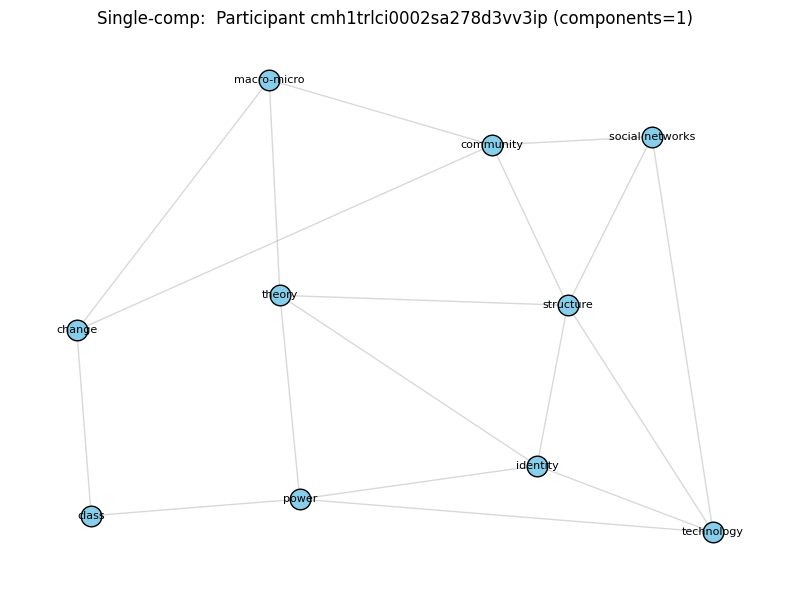

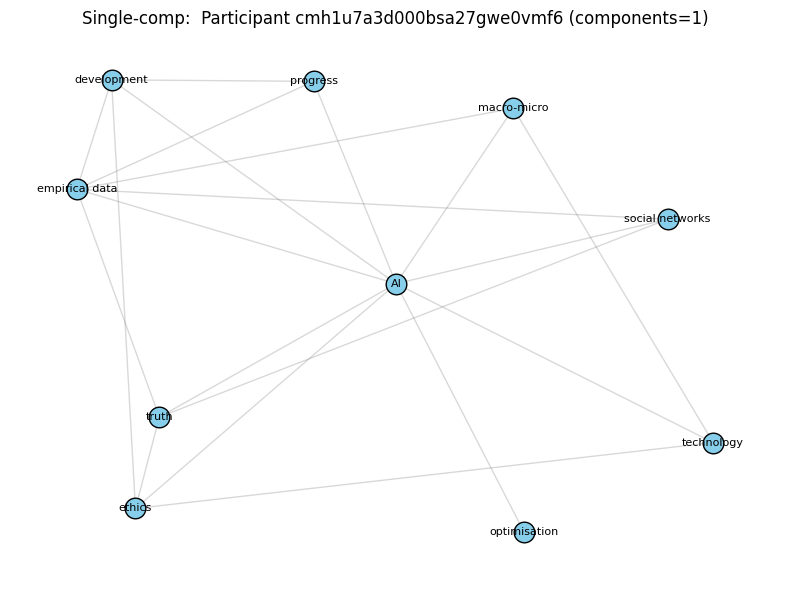

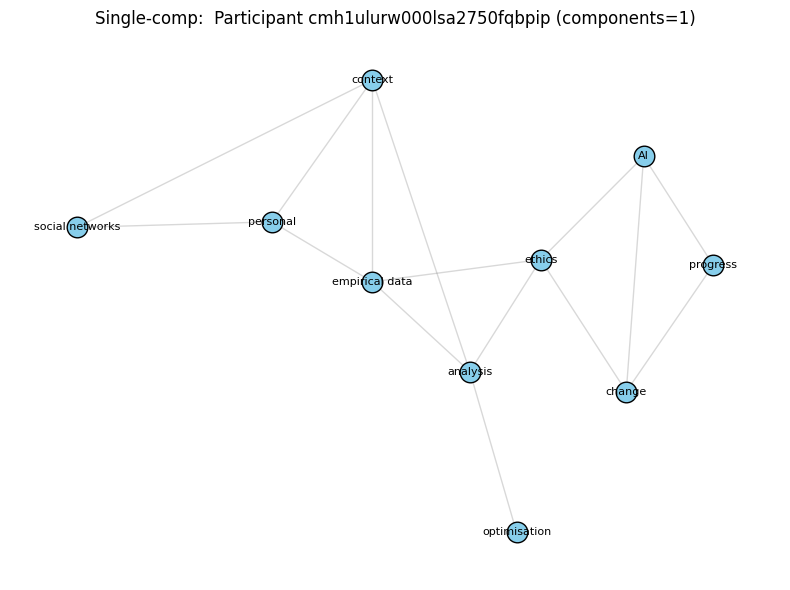

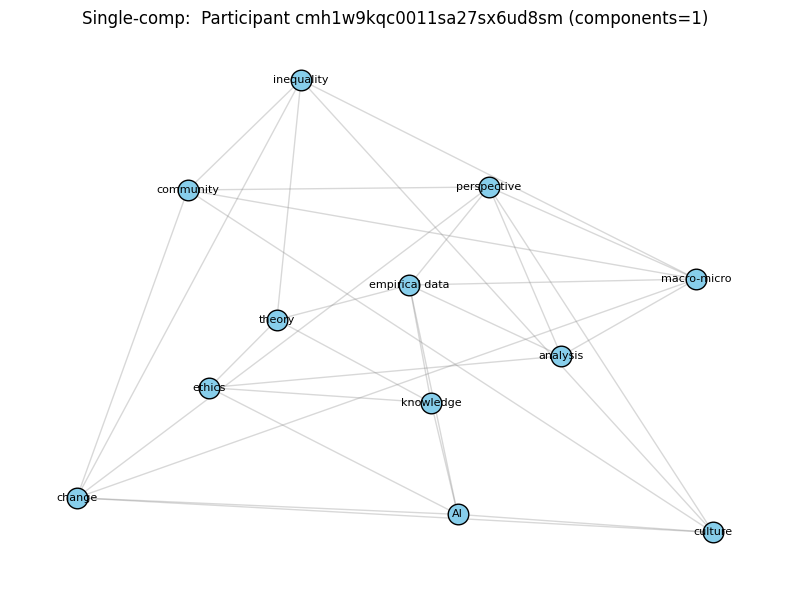

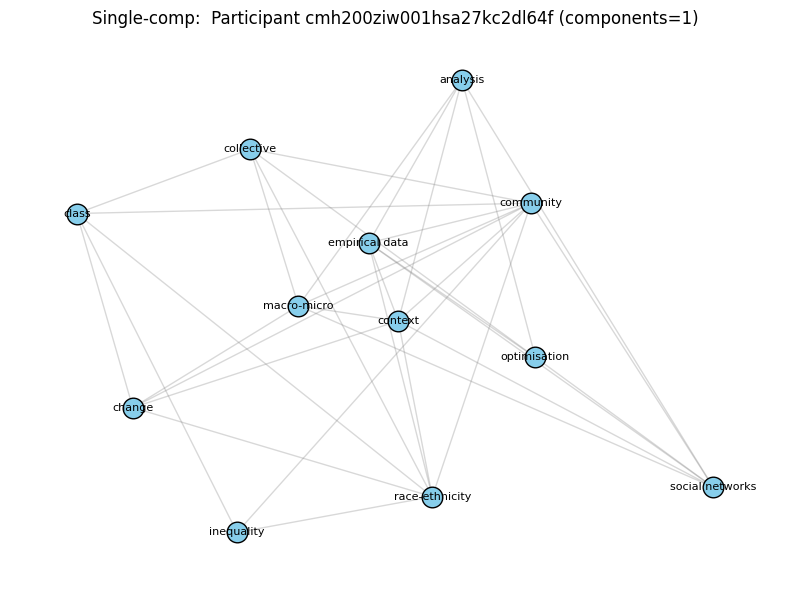

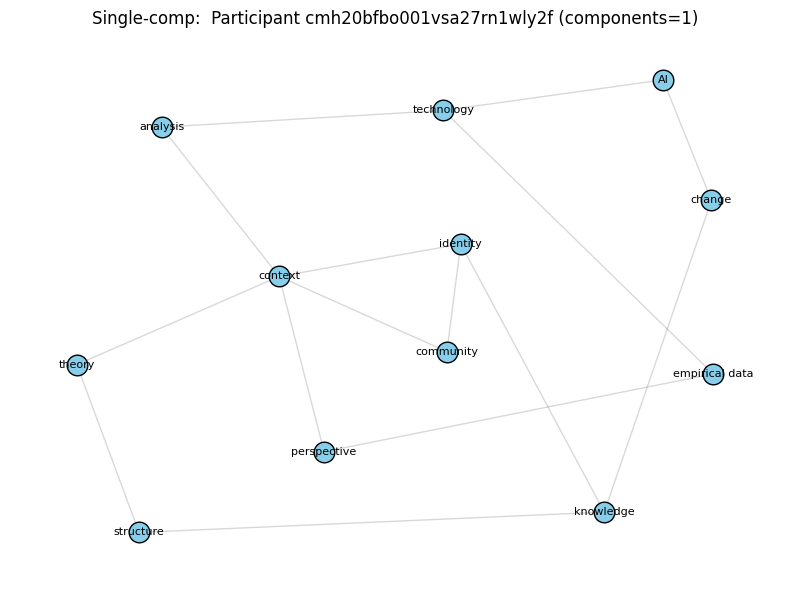

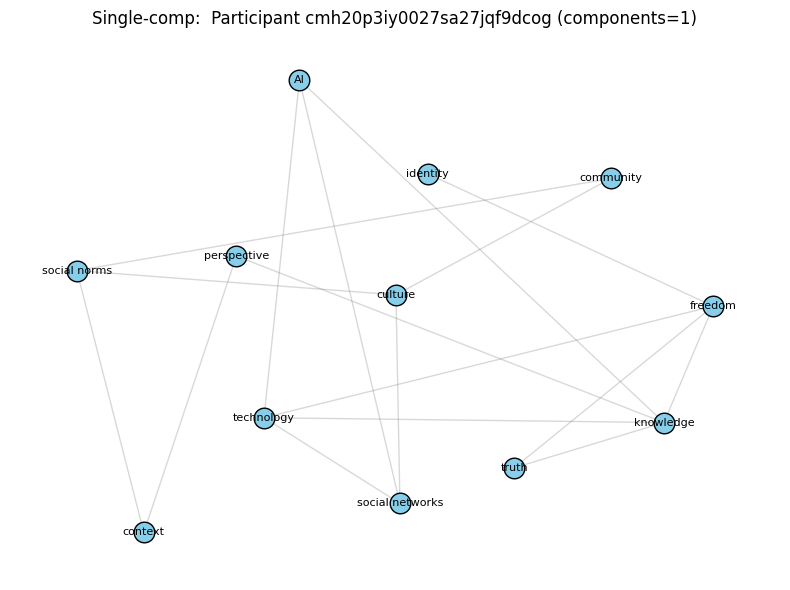

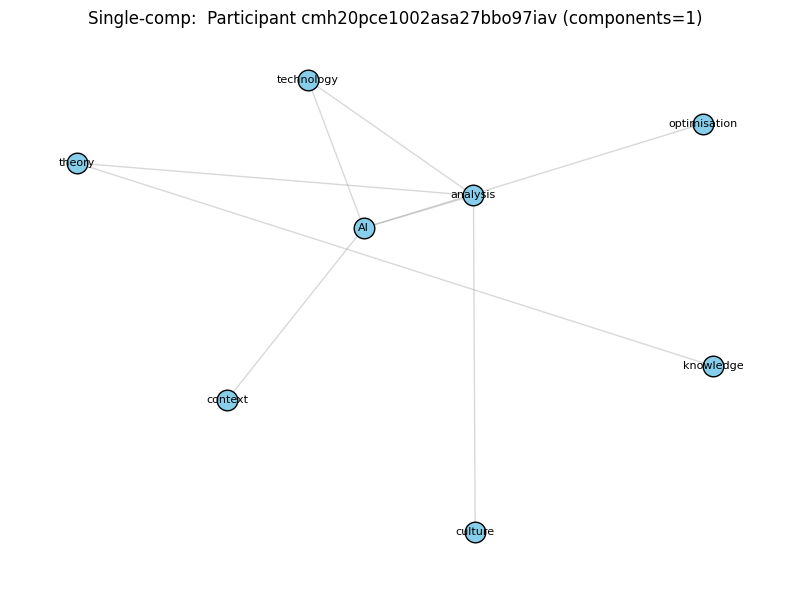

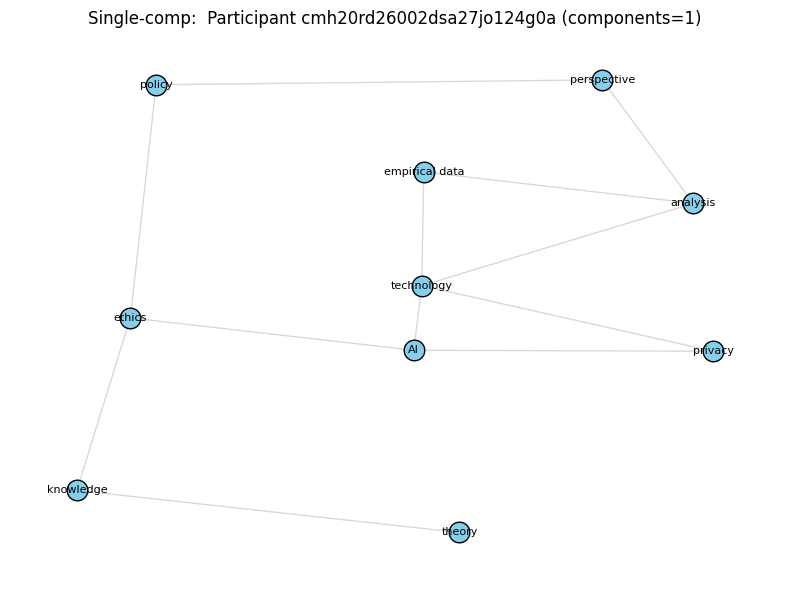

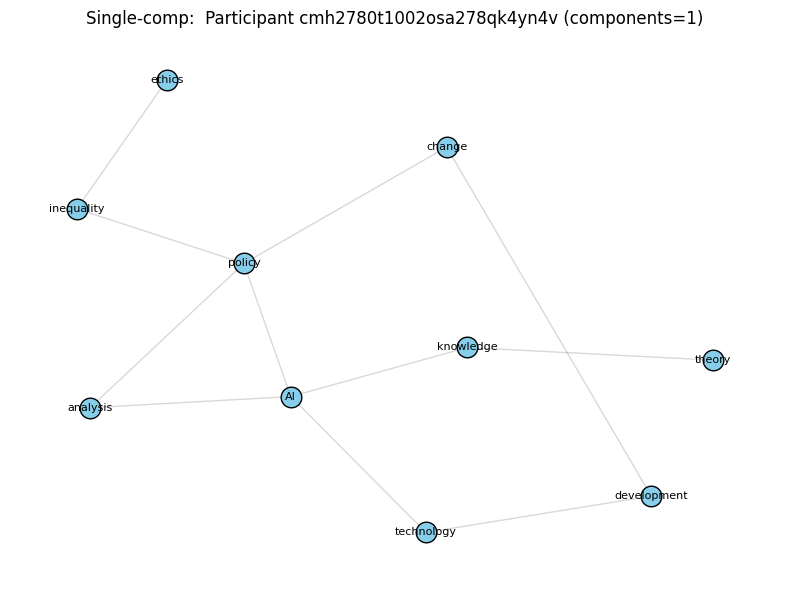

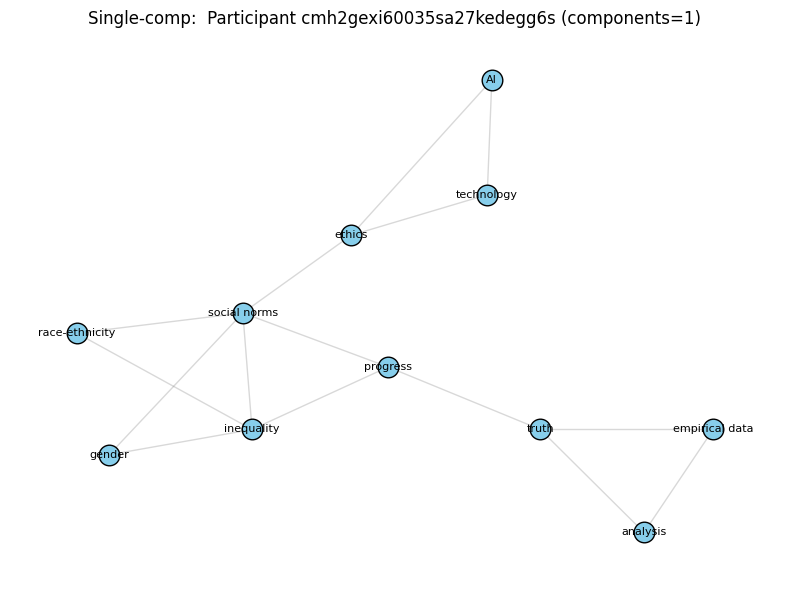

In [43]:
# Plot all participant maps that have exactly one connected component (GCC only)
import os, ast, numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any

OUT_DIR = "./data/per_participant_edges"
os.makedirs(OUT_DIR, exist_ok=True)

UUID_COL = "networkCanvasUUID"
NAME_COL = "name"
CONNECTED_COL = "connected_concepts"
SCREEN_X = "user_layout_screenSpaceX"
SCREEN_Y = "user_layout_screenSpaceY"
ALT_X = "user_layout_x"
ALT_Y = "user_layout_y"

# --- helpers ---
def parse_connected(cell) -> List[str]:
    if pd.isna(cell):
        return []
    if isinstance(cell, (list, tuple)):
        return [str(x) for x in cell]
    s = str(cell).strip()
    if s == "":
        return []
    try:
        val = ast.literal_eval(s)
        if isinstance(val, (list, tuple)):
            return [str(x) for x in val]
    except Exception:
        pass
    s2 = s.strip("[]() ")
    if not s2:
        return []
    return [p.strip().strip("'\"") for p in s2.split(",") if p.strip()]

def build_coords_map(sub: pd.DataFrame) -> Dict[str, Tuple[Any, Any]]:
    coords = {}
    for _, r in sub.iterrows():
        name = r[NAME_COL]
        x = r.get(SCREEN_X) if SCREEN_X in sub.columns else None
        y = r.get(SCREEN_Y) if SCREEN_Y in sub.columns else None
        if (pd.isna(x) or pd.isna(y)) and (ALT_X in sub.columns and ALT_Y in sub.columns):
            x = r.get(ALT_X)
            y = r.get(ALT_Y)
        try:
            x = float(x) if pd.notna(x) else None
        except Exception:
            x = None
        try:
            y = float(y) if pd.notna(y) else None
        except Exception:
            y = None
        coords[name] = (x, y)
    return coords

def construct_participant_graph(sub: pd.DataFrame) -> nx.Graph:
    id_to_name = {str(r[UUID_COL]): r[NAME_COL] for _, r in sub.iterrows() if pd.notna(r.get(UUID_COL))}
    G = nx.Graph()
    for _, r in sub.iterrows():
        name = r[NAME_COL]
        G.add_node(name)
    for _, r in sub.iterrows():
        src_uuid = r.get(UUID_COL)
        if pd.isna(src_uuid):
            continue
        src_uuid = str(src_uuid)
        src_name = id_to_name.get(src_uuid)
        if src_name is None:
            continue
        neighbors = parse_connected(r.get(CONNECTED_COL, ""))
        for nb in neighbors:
            nb = str(nb)
            tgt_name = id_to_name.get(nb)
            if tgt_name is None or src_name == tgt_name:
                continue
            G.add_edge(src_name, tgt_name)
    return G

def plot_map_from_graph(G: nx.Graph, coords: Dict[str, Tuple[Any, Any]], pid: str, 
                        title_prefix: str = "", save: bool = False, jitter_scale: float = 0.03):
    # Known positions
    pos_known = {}
    for n, (x, y) in coords.items():
        if x is not None and y is not None and not (np.isnan(x) or np.isnan(y)):
            pos_known[n] = (float(x), -float(y))
    missing_nodes = [n for n in G.nodes if n not in pos_known]
    pos_complete = dict(pos_known)
    if len(pos_known) > 0:
        xs = np.array([p[0] for p in pos_known.values()])
        ys = np.array([p[1] for p in pos_known.values()])
        x_span = xs.max() - xs.min() if xs.max() != xs.min() else max(1.0, abs(xs.max()))
        y_span = ys.max() - ys.min() if ys.max() != ys.min() else max(1.0, abs(ys.max()))
        jitter_x = jitter_scale * x_span
        jitter_y = jitter_scale * y_span
        centroid = (xs.mean(), ys.mean())
        rng = np.random.default_rng(seed=42)
        for i, n in enumerate(missing_nodes):
            jitter_pos = (centroid[0] + rng.uniform(-1,1)*jitter_x + (i%5)*jitter_x*0.15,
                          centroid[1] + rng.uniform(-1,1)*jitter_y + (i//5)*jitter_y*0.15)
            pos_complete[n] = jitter_pos
    else:
        spring_pos = nx.spring_layout(G, seed=42)
        for n, p in spring_pos.items():
            pos_complete[n] = (p[0]*1000.0, -p[1]*1000.0)

    plt.figure(figsize=(8,6))
    nx.draw_networkx_edges(G, pos_complete, alpha=0.3, edge_color="gray")
    nx.draw_networkx_nodes(G, pos_complete, node_color="skyblue", edgecolors="black", node_size=220)
    nx.draw_networkx_labels(G, pos_complete, font_size=8)
    plt.title(f"{title_prefix} Participant {pid} (components={nx.number_connected_components(G)})", fontsize=12)
    plt.axis("off")
    plt.tight_layout()
    if save:
        out_png = os.path.join(OUT_DIR, f"plot_{pid}.png")
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

# --- main loop: find participants with exactly one connected component ---
participants_one_comp = []
for pid, sub in df.groupby("participant_id"):
    G = construct_participant_graph(sub)
    if nx.number_connected_components(G) == 1:
        participants_one_comp.append(pid)

print(f"Found {len(participants_one_comp)} participants with exactly one connected component: {participants_one_comp}")

# Plot them
for pid in participants_one_comp:
    sub = df[df["participant_id"] == pid].copy()
    coords_map = build_coords_map(sub)
    plot_map_from_graph(construct_participant_graph(sub), coords_map, pid, title_prefix="Single-comp: ", save=False)